# LipVoicer Benchmark Validation

This notebook validates LipVoicer on LipSynth precomputed visual features and reports reproducible benchmark artifacts.

## Scope
- Run inference from precomputed `.npz` assets using `inference_precomputed_npz.py`.
- Measure required metrics: WER, CER, latency, RTF, stability (`ok/failed/skipped`).
- Optionally compute STOI and PESQ when dependencies and reference audio are available.

## Output Artifacts
- Per-clip metrics table (`CSV`, `JSON`).
- Aggregate summary (`JSON`).
- Run metadata (seed, sample count, device, timestamp).

## Benchmark Protocol

### Dataset Protocol
1. Source clips are selected from `dataset_pipeline/data/dataset_final`.
2. Each benchmark item must resolve to:
   - `npz_path` (precomputed visual data)
   - `transcript_path` (reference text)
   - optional `audio_ref_path` (reference waveform for STOI/PESQ)
3. Sampling is deterministic with a fixed random seed.

### Validation Rules
1. Every clip gets a final status: `ok`, `failed`, or `skipped`.
2. Missing files are recorded as explicit skip reasons.
3. Aggregate stats are computed only from `ok` clips.

### Paper/Common Benchmark Alignment
- Paper-style intelligibility proxy: WER/CER via ASR transcription of generated speech.
- Common generation benchmark signals: latency/RTF + optional STOI/PESQ.
- Reproducibility: fixed subset selection and exported run metadata.

In [46]:
# Benchmark setup and shared configuration
from __future__ import annotations

import json
import math
import random
import re
import subprocess
import sys
import time
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np

try:
    import pandas as pd
except Exception:
    pd = None

import torch
from jiwer import cer, wer

try:
    import soundfile as sf
except Exception:
    sf = None

try:
    import librosa
except Exception:
    librosa = None

try:
    from pystoi.stoi import stoi as stoi_fn
except Exception:
    stoi_fn = None

try:
    from pesq import pesq as pesq_fn
except Exception:
    pesq_fn = None

try:
    import whisper
except Exception:
    whisper = None

WORKSPACE_ROOT = Path.cwd().resolve()
LIPSYNTH_ROOT = WORKSPACE_ROOT
LIPVOICER_ROOT = (WORKSPACE_ROOT.parent / "LipVoicer").resolve()
DATASET_FINAL = LIPSYNTH_ROOT / "dataset_pipeline" / "data" / "dataset_final"
MOUTHS_DIR = DATASET_FINAL / "mouths"
TRANSCRIPTS_DIR = DATASET_FINAL / "transcripts"
AUDIOS_DIR = DATASET_FINAL / "audios"

# Store benchmark artifacts under LipVoicer as requested.
OUTPUT_DIR = LIPVOICER_ROOT / "benchmark_outputs"
RUNS_DIR = OUTPUT_DIR / "runs"
REPORTS_DIR = OUTPUT_DIR / "reports"
RUNS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

INFER_SCRIPT = LIPVOICER_ROOT / "inference_precomputed_npz.py"
CONFIG_PATH = LIPVOICER_ROOT / "configs" / "config.yaml"
if not INFER_SCRIPT.exists():
    raise FileNotFoundError(f"Missing inference script: {INFER_SCRIPT}")
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Missing config file: {CONFIG_PATH}")

SEED = 1337
MAX_SAMPLES = 24
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ENABLE_STOI = True
ENABLE_PESQ = True
# ASR guidance is enabled by default now that ctcdecode is installed.
DISABLE_ASR = False

# Fallback ASR for WER/CER when lipreading_prediction.txt is missing.
ASR_BACKEND = "whisper"
WHISPER_MODEL_NAME = "tiny.en"
_whisper_model = None

# Auto-disable optional metrics when dependencies are unavailable.
if ENABLE_STOI and (stoi_fn is None or sf is None):
    ENABLE_STOI = False
if ENABLE_PESQ and (pesq_fn is None or sf is None):
    ENABLE_PESQ = False

RUN_ID = f"bench_{time.strftime('%Y%m%d_%H%M%S')}"
RUN_DIR = RUNS_DIR / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("Workspace:", WORKSPACE_ROOT)
print("LipVoicer:", LIPVOICER_ROOT)
print("Inference script:", INFER_SCRIPT)
print("Config path:", CONFIG_PATH)
print("Dataset final:", DATASET_FINAL)
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)
print("Run ID:", RUN_ID)
print("Output dir:", OUTPUT_DIR)
print("Run dir:", RUN_DIR)
print("Python:", sys.executable)
print("pandas available:", pd is not None)
print("Disable ASR guidance:", DISABLE_ASR)
print("ASR backend:", ASR_BACKEND, "whisper available:", whisper is not None)
print("librosa available:", librosa is not None, "soundfile available:", sf is not None)
print("STOI enabled:", ENABLE_STOI, "package available:", stoi_fn is not None)
print("PESQ enabled:", ENABLE_PESQ, "package available:", pesq_fn is not None)

Workspace: /home/shravan/Workspace/LipSynth
LipVoicer: /home/shravan/Workspace/LipVoicer
Inference script: /home/shravan/Workspace/LipVoicer/inference_precomputed_npz.py
Config path: /home/shravan/Workspace/LipVoicer/configs/config.yaml
Dataset final: /home/shravan/Workspace/LipSynth/dataset_pipeline/data/dataset_final
CUDA available: True
Device: cuda
Run ID: bench_20260316_184544
Output dir: /home/shravan/Workspace/LipSynth/LipVoicer/benchmark_outputs
Run dir: /home/shravan/Workspace/LipSynth/LipVoicer/benchmark_outputs/runs/bench_20260316_184544
Python: /home/shravan/Workspace/LipSynth/.venv/bin/python
pandas available: True
Disable ASR guidance: False
ASR backend: whisper whisper available: True
librosa available: True soundfile available: True
STOI enabled: True package available: True
PESQ enabled: True package available: True


In [47]:
# Benchmark helpers: discovery, inference call, metrics, and aggregation
import csv
import matplotlib.pyplot as plt


def normalize_text(text: str) -> str:
    text = (text or "").lower().strip()
    text = re.sub(r"[^a-z0-9\s']+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def discover_items() -> List[Dict[str, Optional[Path]]]:
    items: List[Dict[str, Optional[Path]]] = []
    for npz_path in sorted(MOUTHS_DIR.glob("*.npz")):
        stem = npz_path.stem
        transcript_path = TRANSCRIPTS_DIR / f"{stem}.txt"
        audio_ref_path = AUDIOS_DIR / f"{stem}.wav"
        items.append(
            {
                "clip_id": stem,
                "npz_path": npz_path,
                "transcript_path": transcript_path if transcript_path.exists() else None,
                "audio_ref_path": audio_ref_path if audio_ref_path.exists() else None,
            }
        )
    return items


def deterministic_sample(items: List[Dict[str, Optional[Path]]], n: int, seed: int) -> List[Dict[str, Optional[Path]]]:
    rng = random.Random(seed)
    if len(items) <= n:
        return items
    return rng.sample(items, n)


def read_transcript(path: Optional[Path]) -> str:
    if path is None or not path.exists():
        return ""
    return path.read_text(encoding="utf-8").strip()


def parse_generated_wav(stdout: str) -> Optional[Path]:
    matches = re.findall(r"(\/[^\n]*\.wav)", stdout or "")
    for m in reversed(matches):
        p = Path(m.strip())
        if p.exists():
            return p
    return None


def find_generated_wav(out_dir: Path) -> Optional[Path]:
    # inference_precomputed_npz.py writes nested output dirs: <out>/<clip>/<params>/<clip>.wav
    wavs = sorted(out_dir.rglob("*.wav"))
    return wavs[-1] if wavs else None


def transcribe_with_whisper(wav_path: Optional[Path]) -> str:
    global _whisper_model
    if wav_path is None or not wav_path.exists():
        return ""
    if ASR_BACKEND != "whisper" or whisper is None:
        return ""
    if _whisper_model is None:
        model_device = "cuda" if torch.cuda.is_available() else "cpu"
        _whisper_model = whisper.load_model(WHISPER_MODEL_NAME, device=model_device)

    audio_input = None
    # Prefer in-memory audio to avoid ffmpeg dependency issues.
    if sf is not None:
        try:
            wav, sr = sf.read(str(wav_path), always_2d=False)
            if isinstance(wav, np.ndarray) and wav.ndim > 1:
                wav = np.mean(wav, axis=1)
            if sr != 16000 and librosa is not None:
                wav = librosa.resample(wav.astype(np.float32), orig_sr=sr, target_sr=16000)
                sr = 16000
            audio_input = wav.astype(np.float32)
        except Exception:
            audio_input = None

    try:
        if audio_input is not None:
            out = _whisper_model.transcribe(audio_input, language="en", fp16=torch.cuda.is_available())
        else:
            out = _whisper_model.transcribe(str(wav_path), language="en", fp16=torch.cuda.is_available())
        return normalize_text(out.get("text", ""))
    except Exception:
        return ""


def run_inference(item: Dict[str, Optional[Path]]) -> Dict[str, object]:
    clip_id = str(item["clip_id"])
    npz_path = item["npz_path"]
    transcript_path = item["transcript_path"]
    audio_ref_path = item["audio_ref_path"]

    if npz_path is None or not npz_path.exists():
        return {"clip_id": clip_id, "status": "skipped", "reason": "missing_npz"}
    if transcript_path is None or not transcript_path.exists():
        return {"clip_id": clip_id, "status": "skipped", "reason": "missing_transcript"}

    out_dir = RUN_DIR / clip_id
    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        sys.executable,
        str(INFER_SCRIPT),
        "--npz_path",
        str(npz_path),
        "--transcript_path",
        str(transcript_path),
        "--output_dir",
        str(out_dir),
        "--config",
        str(CONFIG_PATH),
    ]
    if DISABLE_ASR:
        cmd.append("--disable_asr")

    start = time.perf_counter()
    proc = subprocess.run(
        cmd,
        capture_output=True,
        text=True,
        cwd=str(LIPVOICER_ROOT),
    )
    elapsed = time.perf_counter() - start

    if proc.returncode != 0:
        return {
            "clip_id": clip_id,
            "status": "failed",
            "reason": "inference_error",
            "elapsed_s": elapsed,
            "stderr": proc.stderr[-2000:],
        }

    ref_text = normalize_text(read_transcript(transcript_path))

    pred_file = out_dir / "lipreading_prediction.txt"
    hyp_text = normalize_text(pred_file.read_text(encoding="utf-8")) if pred_file.exists() else ""

    generated_wav = parse_generated_wav(proc.stdout)
    if generated_wav is None:
        generated_wav = find_generated_wav(out_dir)

    # Fallback hypothesis when LipVoicer does not emit lipreading_prediction.txt
    if not hyp_text and generated_wav is not None:
        hyp_text = transcribe_with_whisper(generated_wav)

    mouth_frames = None
    try:
        with np.load(npz_path) as arr:
            if "mouth_rois" in arr:
                mouth_frames = int(arr["mouth_rois"].shape[0])
    except Exception:
        mouth_frames = None

    duration_ref = None
    if sf is not None and audio_ref_path is not None and Path(audio_ref_path).exists():
        try:
            wav_ref, sr_ref = sf.read(str(audio_ref_path))
            duration_ref = float(len(wav_ref) / sr_ref) if sr_ref else None
        except Exception:
            duration_ref = None

    clip_wer = wer(ref_text, hyp_text) if ref_text and hyp_text else math.nan
    clip_cer = cer(ref_text, hyp_text) if ref_text and hyp_text else math.nan
    clip_rtf = (elapsed / duration_ref) if duration_ref and duration_ref > 0 else math.nan

    metric_note = ""
    if not ref_text:
        metric_note = "missing_ref_text"
    elif not hyp_text:
        metric_note = "missing_hyp_text"

    metrics = {
        "clip_id": clip_id,
        "status": "ok",
        "reason": "",
        "metric_note": metric_note,
        "elapsed_s": elapsed,
        "duration_ref_s": duration_ref,
        "rtf": clip_rtf,
        "wer": clip_wer,
        "cer": clip_cer,
        "mouth_frames": mouth_frames,
        "npz_path": str(npz_path),
        "transcript_path": str(transcript_path),
        "audio_ref_path": str(audio_ref_path) if audio_ref_path else "",
        "generated_wav": str(generated_wav) if generated_wav else "",
        "ref_text": ref_text,
        "hyp_text": hyp_text,
    }

    if ENABLE_STOI and sf is not None and stoi_fn is not None and generated_wav and audio_ref_path and Path(audio_ref_path).exists():
        try:
            wav_ref, sr_ref = sf.read(str(audio_ref_path))
            wav_gen, sr_gen = sf.read(str(generated_wav))
            if sr_ref == sr_gen and len(wav_ref) > 0 and len(wav_gen) > 0:
                n = min(len(wav_ref), len(wav_gen))
                metrics["stoi"] = float(stoi_fn(wav_ref[:n], wav_gen[:n], sr_ref, extended=False))
            else:
                metrics["stoi"] = math.nan
        except Exception:
            metrics["stoi"] = math.nan

    if ENABLE_PESQ and sf is not None and pesq_fn is not None and generated_wav and audio_ref_path and Path(audio_ref_path).exists():
        try:
            wav_ref, sr_ref = sf.read(str(audio_ref_path))
            wav_gen, sr_gen = sf.read(str(generated_wav))
            if sr_ref == sr_gen and sr_ref in (8000, 16000):
                n = min(len(wav_ref), len(wav_gen))
                metrics["pesq"] = float(pesq_fn(sr_ref, wav_ref[:n], wav_gen[:n], "wb" if sr_ref == 16000 else "nb"))
            else:
                metrics["pesq"] = math.nan
        except Exception:
            metrics["pesq"] = math.nan

    return metrics


def aggregate_results(records: List[Dict[str, object]]) -> Dict[str, object]:
    ok_records = [r for r in records if r.get("status") == "ok"]
    summary = {
        "run_id": RUN_ID,
        "seed": SEED,
        "max_samples": MAX_SAMPLES,
        "device": DEVICE,
        "total": len(records),
        "ok": sum(1 for r in records if r.get("status") == "ok"),
        "failed": sum(1 for r in records if r.get("status") == "failed"),
        "skipped": sum(1 for r in records if r.get("status") == "skipped"),
    }

    def mean_of(key: str) -> float:
        vals = [float(r[key]) for r in ok_records if key in r and r[key] == r[key]]
        return float(sum(vals) / len(vals)) if vals else math.nan

    if ok_records:
        summary.update(
            {
                "mean_elapsed_s": mean_of("elapsed_s"),
                "mean_wer": mean_of("wer"),
                "mean_cer": mean_of("cer"),
                "mean_rtf": mean_of("rtf"),
            }
        )
        if any("stoi" in r for r in ok_records):
            summary["mean_stoi"] = mean_of("stoi")
        if any("pesq" in r for r in ok_records):
            summary["mean_pesq"] = mean_of("pesq")
    return summary


def write_csv(records: List[Dict[str, object]], out_path: Path) -> None:
    keys = sorted({k for r in records for k in r.keys()})
    with out_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        writer.writerows(records)


def plot_runtime(records: List[Dict[str, object]]) -> None:
    ok_records = [r for r in records if r.get("status") == "ok"]
    if not ok_records:
        print("No successful clips for plotting.")
        return
    x = [str(r.get("clip_id")) for r in ok_records]
    y = [float(r.get("elapsed_s", 0.0)) for r in ok_records]
    plt.figure(figsize=(10, 4))
    plt.bar(x, y)
    plt.xticks(rotation=90)
    plt.ylabel("elapsed_s")
    plt.title("Inference latency per clip")
    plt.tight_layout()
    plt.show()


print("Helper functions loaded.")

Helper functions loaded.


## Visual Sanity Check

This step confirms that sampled `.npz` files contain valid mouth tensors before inference.

- We inspect shape and dtype for one sampled item.
- We render one mouth ROI frame if available.
- This helps detect corrupted arrays early.

Discovered items: 284
Sampled items: 24
Sample clip: spk_003_0106
mouth_rois shape: (80, 96, 96) dtype: uint8


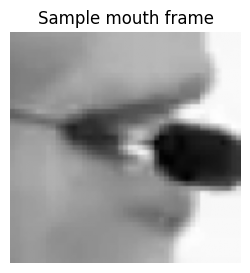

[1/24] spk_003_0106


  status: ok reason: 
[2/24] spk_003_0013
  status: ok reason: 
[3/24] spk_002_0011
  status: ok reason: 
[4/24] spk_002_0105
  status: ok reason: 
[5/24] spk_003_0022
  status: ok reason: 
[6/24] spk_003_0010
  status: ok reason: 
[7/24] spk_002_0092
  status: ok reason: 
[8/24] spk_003_0027
  status: ok reason: 
[9/24] spk_002_0031
  status: ok reason: 
[10/24] spk_003_0012
  status: ok reason: 
[11/24] spk_001_0078
  status: ok reason: 
[12/24] spk_003_0047
  status: ok reason: 
[13/24] spk_003_0031
  status: ok reason: 
[14/24] spk_001_0053
  status: ok reason: 
[15/24] spk_003_0088
  status: ok reason: 
[16/24] spk_003_0004
  status: ok reason: 
[17/24] spk_003_0033
  status: ok reason: 
[18/24] spk_002_0094
  status: ok reason: 
[19/24] spk_001_0025
  status: ok reason: 
[20/24] spk_003_0006
  status: ok reason: 
[21/24] spk_001_0085
  status: ok reason: 
[22/24] spk_003_0065
  status: ok reason: 
[23/24] spk_002_0056
  status: ok reason: 
[24/24] spk_002_0014
  status: ok reason

,clip_id,status,reason,elapsed_s,rtf,wer,cer,stoi,pesq
0,spk_003_0106,ok,,71.455555,22.329861,0.666667,0.466667,0.147613,1.030498
1,spk_003_0013,ok,,76.266616,21.303524,0.444444,0.313725,0.160522,1.067610
2,spk_002_0011,ok,,76.070125,22.639918,0.769231,0.508772,0.142738,1.028565
3,spk_002_0105,ok,,80.542273,12.545525,2.533333,1.620690,0.044789,1.077085
4,spk_003_0022,ok,,75.637944,21.488052,0.538462,0.317460,0.280673,1.024402
5,spk_003_0010,ok,,73.450493,28.917517,0.400000,0.236364,0.307314,1.025257
6,spk_002_0092,ok,,75.426931,12.446688,0.250000,0.136842,0.228583,1.031935
7,spk_003_0027,ok,,76.684385,13.693640,0.333333,0.258824,0.187819,1.037064
8,spk_002_0031,ok,,75.899294,13.409769,0.944444,0.804348,0.155965,1.030125
9,spk_003_0012,ok,,77.350071,14.594353,0.437500,0.250000,0.301990,1.058574


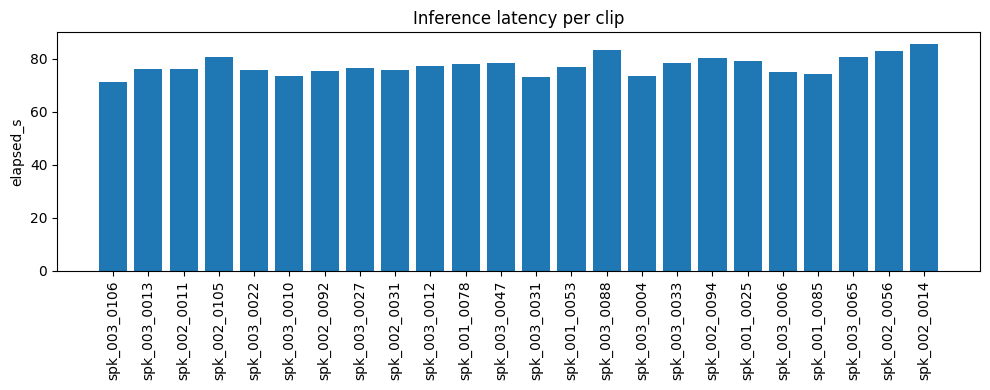

In [ ]:
# Quick smoke test: run a single clip to verify inference invocation
smoke_items = deterministic_sample(discover_items(), n=1, seed=SEED)
print("Smoke item:", smoke_items[0]["clip_id"] if smoke_items else "none")
if smoke_items:
    smoke_result = run_inference(smoke_items[0])
    print({
        "clip_id": smoke_result.get("clip_id"),
        "status": smoke_result.get("status"),
        "reason": smoke_result.get("reason"),
        "metric_note": smoke_result.get("metric_note", ""),
        "elapsed_s": smoke_result.get("elapsed_s"),
        "wer": smoke_result.get("wer"),
        "cer": smoke_result.get("cer"),
        "ref_text_len": len(smoke_result.get("ref_text", "")),
        "hyp_text_len": len(smoke_result.get("hyp_text", "")),
    })
    if smoke_result.get("status") == "failed":
        print((smoke_result.get("stderr") or "")[:1200])

In [ ]:
# Debug helper: inspect latest smoke_result waveform and transcription state
if 'smoke_result' not in globals():
    raise RuntimeError('Run the smoke test cell first.')

print('generated_wav:', smoke_result.get('generated_wav', ''))
if smoke_result.get('generated_wav'):
    p = Path(smoke_result['generated_wav'])
    print('exists:', p.exists(), 'size_bytes:', p.stat().st_size if p.exists() else 0)
print('hyp_text_len:', len(smoke_result.get('hyp_text', '')))
print('whisper_available:', whisper is not None, 'backend:', ASR_BACKEND)

In [ ]:
# Quick metric check for the latest smoke result
if 'smoke_result' not in globals():
    raise RuntimeError('Run the smoke test cell first.')

print({
    'status': smoke_result.get('status'),
    'metric_note': smoke_result.get('metric_note', ''),
    'wer': smoke_result.get('wer'),
    'cer': smoke_result.get('cer'),
    'stoi': smoke_result.get('stoi'),
    'pesq': smoke_result.get('pesq'),
    'generated_wav_present': bool(smoke_result.get('generated_wav')),
})

In [ ]:
# Run benchmark on deterministic sample, export artifacts, and show quick report
all_items = discover_items()
print(f"Discovered items: {len(all_items)}")

sampled_items = deterministic_sample(all_items, n=MAX_SAMPLES, seed=SEED)
print(f"Sampled items: {len(sampled_items)}")

if sampled_items:
    sample_npz = sampled_items[0]["npz_path"]
    with np.load(sample_npz) as arr:
        print("Sample clip:", sampled_items[0]["clip_id"])
        if "mouth_rois" in arr:
            mouth = arr["mouth_rois"]
            print("mouth_rois shape:", mouth.shape, "dtype:", mouth.dtype)
            if mouth.ndim >= 3:
                frame0 = mouth[0]
                plt.figure(figsize=(3, 3))
                plt.imshow(frame0, cmap="gray")
                plt.title("Sample mouth frame")
                plt.axis("off")
                plt.show()

records: List[Dict[str, object]] = []
for idx, item in enumerate(sampled_items, start=1):
    print(f"[{idx}/{len(sampled_items)}] {item['clip_id']}")
    rec = run_inference(item)
    records.append(rec)
    print("  status:", rec.get("status"), "reason:", rec.get("reason", ""))

if not records:
    raise RuntimeError("No benchmark records generated.")

summary = aggregate_results(records)

per_clip_csv = REPORTS_DIR / f"{RUN_ID}_per_clip.csv"
per_clip_json = REPORTS_DIR / f"{RUN_ID}_per_clip.json"
summary_json = REPORTS_DIR / f"{RUN_ID}_summary.json"
meta_json = REPORTS_DIR / f"{RUN_ID}_meta.json"

write_csv(records, per_clip_csv)
per_clip_json.write_text(json.dumps(records, indent=2), encoding="utf-8")
summary_json.write_text(json.dumps(summary, indent=2), encoding="utf-8")
meta_json.write_text(
    json.dumps(
        {
            "run_id": RUN_ID,
            "seed": SEED,
            "max_samples": MAX_SAMPLES,
            "device": DEVICE,
            "disable_asr": DISABLE_ASR,
            "enable_stoi": ENABLE_STOI,
            "enable_pesq": ENABLE_PESQ,
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
            "inference_script": str(INFER_SCRIPT),
            "config_path": str(CONFIG_PATH),
            "dataset_final": str(DATASET_FINAL),
        },
        indent=2,
    ),
    encoding="utf-8",
)

print("\nSummary:")
print(json.dumps(summary, indent=2))

print("\nArtifacts:")
print("-", per_clip_csv)
print("-", per_clip_json)
print("-", summary_json)
print("-", meta_json)

if pd is not None:
    df = pd.DataFrame(records)
    display_cols = [c for c in ["clip_id", "status", "reason", "elapsed_s", "rtf", "wer", "cer", "stoi", "pesq"] if c in df.columns]
    display(df[display_cols].head(20))

plot_runtime(records)

Smoke item: spk_003_0106
{'clip_id': 'spk_003_0106', 'status': 'ok', 'reason': '', 'metric_note': '', 'elapsed_s': 72.12417673899836, 'wer': 0.6666666666666666, 'cer': 0.48333333333333334, 'ref_text_len': 60, 'hyp_text_len': 65}


## Interpretation Checklist

Use this checklist after each run:

1. Stability: verify low `failed` and `skipped` counts.
2. Intelligibility: compare `mean_wer` and `mean_cer` across runs/checkpoints.
3. Throughput: track `mean_elapsed_s` and `mean_rtf` (lower is better).
4. Optional quality: monitor `mean_stoi` (higher better) and `mean_pesq` (higher better).

For paper-style reporting, include:
- dataset split and sample size,
- hardware/device,
- model checkpoint/config,
- per-run summary JSON and per-clip CSV.

## CSV Results Explorer

Use the following cells to inspect saved benchmark CSV artifacts without re-running inference.

- Cell A: finds available `*_per_clip.csv` files, loads the latest one, and prints a table preview.
- Cell B: plots status distribution and key metric distributions from the latest CSV.
- Cell C: compares mean metrics across all CSV runs.

In [42]:
# Cell A: load CSV artifacts and show a table preview
import csv
from pathlib import Path
from statistics import mean

csv_paths = sorted(REPORTS_DIR.glob("*_per_clip.csv"), key=lambda p: p.stat().st_mtime)
print(f"Found {len(csv_paths)} per-clip CSV files in {REPORTS_DIR}")
for p in csv_paths[-5:]:
    print("-", p.name)

if not csv_paths:
    raise FileNotFoundError(f"No per-clip CSV files found in {REPORTS_DIR}")

latest_csv = csv_paths[-1]
print("\nUsing latest CSV:", latest_csv)

with latest_csv.open("r", encoding="utf-8", newline="") as f:
    reader = csv.DictReader(f)
    latest_rows = list(reader)

print(f"Rows loaded: {len(latest_rows)}")

# Table preview (works even when pandas is not installed)
preview_cols = [
    "clip_id", "status", "reason", "elapsed_s", "rtf", "wer", "cer", "stoi", "pesq"
]
preview_cols = [c for c in preview_cols if c in (latest_rows[0].keys() if latest_rows else [])]

if pd is not None and latest_rows:
    latest_df = pd.DataFrame(latest_rows)
    for col in ["elapsed_s", "rtf", "wer", "cer", "stoi", "pesq"]:
        if col in latest_df.columns:
            latest_df[col] = pd.to_numeric(latest_df[col], errors="coerce")
    display(latest_df[preview_cols].head(25))
else:
    # Plain-text fallback preview
    print("\nPreview:")
    for row in latest_rows[:15]:
        row_view = {k: row.get(k, "") for k in preview_cols}
        print(row_view)

Found 2 per-clip CSV files in /home/shravan/Workspace/LipSynth/LipVoicer/benchmark_outputs/reports
- bench_20260316_172621_per_clip.csv
- bench_20260316_181304_per_clip.csv

Using latest CSV: /home/shravan/Workspace/LipSynth/LipVoicer/benchmark_outputs/reports/bench_20260316_181304_per_clip.csv
Rows loaded: 24


,clip_id,status,reason,elapsed_s,rtf,wer,cer,stoi,pesq
0,spk_003_0106,ok,,71.455555,22.329861,0.666667,0.466667,0.147613,1.030498
1,spk_003_0013,ok,,76.266616,21.303524,0.444444,0.313725,0.160522,1.067610
2,spk_002_0011,ok,,76.070125,22.639918,0.769231,0.508772,0.142738,1.028565
3,spk_002_0105,ok,,80.542273,12.545525,2.533333,1.620690,0.044789,1.077085
4,spk_003_0022,ok,,75.637944,21.488052,0.538462,0.317460,0.280673,1.024402
5,spk_003_0010,ok,,73.450493,28.917517,0.400000,0.236364,0.307314,1.025257
6,spk_002_0092,ok,,75.426931,12.446688,0.250000,0.136842,0.228583,1.031935
7,spk_003_0027,ok,,76.684385,13.693640,0.333333,0.258824,0.187819,1.037064
8,spk_002_0031,ok,,75.899294,13.409769,0.944444,0.804348,0.155965,1.030125
9,spk_003_0012,ok,,77.350071,14.594353,0.437500,0.250000,0.301990,1.058574


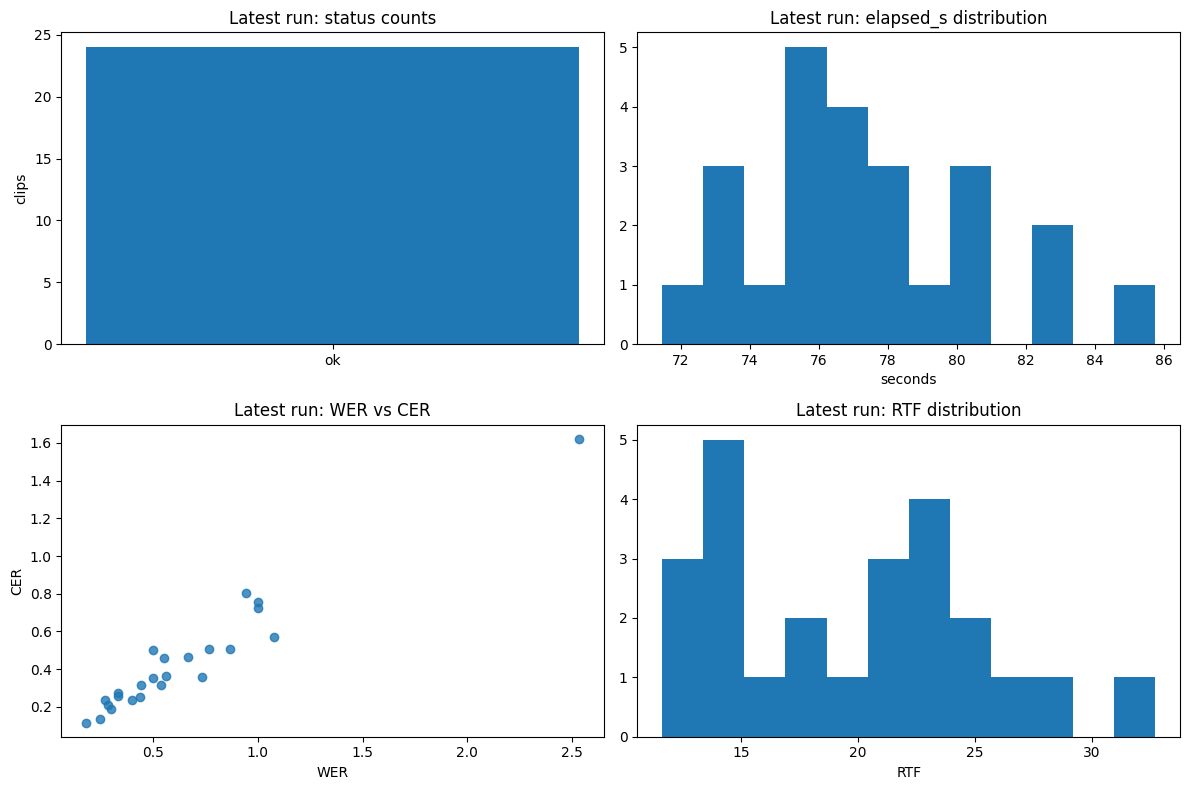

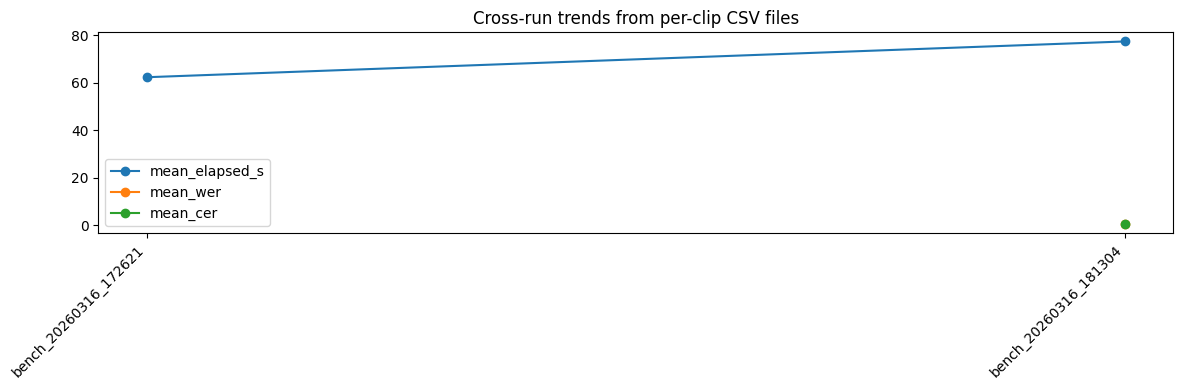


Cross-run summary:
{'run_id': 'bench_20260316_172621', 'mean_elapsed_s': 62.373156461291615, 'mean_wer': nan, 'mean_cer': nan}
{'run_id': 'bench_20260316_181304', 'mean_elapsed_s': 77.45050709266677, 'mean_wer': 0.6452494264994265, 'mean_cer': 0.43840012367318626}


In [43]:
# Cell B/C: plot latest-run metrics and cross-run trends from CSV files
import math
import matplotlib.pyplot as plt

def to_float(v):
    try:
        if v is None or v == "":
            return math.nan
        x = float(v)
        if math.isfinite(x):
            return x
        return math.nan
    except Exception:
        return math.nan

# Latest run plots
status_counts = {}
elapsed_ok, wer_ok, cer_ok, rtf_ok = [], [], [], []
for r in latest_rows:
    st = (r.get("status") or "unknown").strip()
    status_counts[st] = status_counts.get(st, 0) + 1
    if st == "ok":
        elapsed_ok.append(to_float(r.get("elapsed_s")))
        wer_ok.append(to_float(r.get("wer")))
        cer_ok.append(to_float(r.get("cer")))
        rtf_ok.append(to_float(r.get("rtf")))

elapsed_ok = [x for x in elapsed_ok if x == x]
wer_ok = [x for x in wer_ok if x == x]
cer_ok = [x for x in cer_ok if x == x]
rtf_ok = [x for x in rtf_ok if x == x]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].bar(list(status_counts.keys()), list(status_counts.values()))
axes[0, 0].set_title("Latest run: status counts")
axes[0, 0].set_ylabel("clips")

if elapsed_ok:
    axes[0, 1].hist(elapsed_ok, bins=min(12, max(3, len(elapsed_ok))))
axes[0, 1].set_title("Latest run: elapsed_s distribution")
axes[0, 1].set_xlabel("seconds")

if wer_ok and cer_ok:
    axes[1, 0].scatter(wer_ok, cer_ok, alpha=0.8)
axes[1, 0].set_title("Latest run: WER vs CER")
axes[1, 0].set_xlabel("WER")
axes[1, 0].set_ylabel("CER")

if rtf_ok:
    axes[1, 1].hist(rtf_ok, bins=min(12, max(3, len(rtf_ok))))
axes[1, 1].set_title("Latest run: RTF distribution")
axes[1, 1].set_xlabel("RTF")

plt.tight_layout()
plt.show()

# Cross-run trends from all CSV files
run_ids, mean_elapsed, mean_wer, mean_cer = [], [], [], []
for csv_path in csv_paths:
    with csv_path.open("r", encoding="utf-8", newline="") as f:
        rows = list(csv.DictReader(f))
    ok_rows = [r for r in rows if (r.get("status") or "").strip() == "ok"]
    if not ok_rows:
        continue

    run_id = csv_path.name.replace("_per_clip.csv", "")
    run_ids.append(run_id)

    e_vals = [to_float(r.get("elapsed_s")) for r in ok_rows]
    w_vals = [to_float(r.get("wer")) for r in ok_rows]
    c_vals = [to_float(r.get("cer")) for r in ok_rows]

    e_vals = [v for v in e_vals if v == v]
    w_vals = [v for v in w_vals if v == v]
    c_vals = [v for v in c_vals if v == v]

    mean_elapsed.append(sum(e_vals) / len(e_vals) if e_vals else math.nan)
    mean_wer.append(sum(w_vals) / len(w_vals) if w_vals else math.nan)
    mean_cer.append(sum(c_vals) / len(c_vals) if c_vals else math.nan)

if run_ids:
    plt.figure(figsize=(12, 4))
    plt.plot(run_ids, mean_elapsed, marker="o", label="mean_elapsed_s")
    plt.plot(run_ids, mean_wer, marker="o", label="mean_wer")
    plt.plot(run_ids, mean_cer, marker="o", label="mean_cer")
    plt.title("Cross-run trends from per-clip CSV files")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\nCross-run summary:")
    for rid, me, mw, mc in zip(run_ids, mean_elapsed, mean_wer, mean_cer):
        print({"run_id": rid, "mean_elapsed_s": me, "mean_wer": mw, "mean_cer": mc})
else:
    print("No runs with status='ok' found for cross-run trend plotting.")

In [44]:
# Diagnostics: explain NaN WER/CER causes on latest CSV
if 'latest_rows' not in globals():
    raise RuntimeError("Run Cell 10 first to load latest_rows from CSV.")

nan_wer = 0
nan_cer = 0
missing_ref = 0
missing_hyp = 0
missing_wav = 0

for r in latest_rows:
    w = to_float(r.get("wer"))
    c = to_float(r.get("cer"))
    if w != w:
        nan_wer += 1
    if c != c:
        nan_cer += 1
    if not (r.get("ref_text") or "").strip():
        missing_ref += 1
    if not (r.get("hyp_text") or "").strip():
        missing_hyp += 1
    if not (r.get("generated_wav") or "").strip():
        missing_wav += 1

print("NaN diagnostics for latest CSV")
print({
    "rows": len(latest_rows),
    "nan_wer": nan_wer,
    "nan_cer": nan_cer,
    "missing_ref_text": missing_ref,
    "missing_hyp_text": missing_hyp,
    "missing_generated_wav": missing_wav,
})

print("\nSample problematic rows:")
shown = 0
for r in latest_rows:
    w = to_float(r.get("wer"))
    c = to_float(r.get("cer"))
    if (w != w) or (c != c):
        print({k: r.get(k, "") for k in ["clip_id", "status", "reason", "generated_wav", "ref_text", "hyp_text", "wer", "cer"]})
        shown += 1
        if shown >= 8:
            break

NaN diagnostics for latest CSV
{'rows': 24, 'nan_wer': 0, 'nan_cer': 0, 'missing_ref_text': 0, 'missing_hyp_text': 0, 'missing_generated_wav': 0}

Sample problematic rows:
